In [69]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [70]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [71]:
# separate the features X and the target/labels y
X = df[['total_bill']]
# scalar = StandardScaler()
scalar = MinMaxScaler()
X = scalar.fit_transform(X)
y = df['tip']

In [72]:
# train test split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

In [73]:
# call and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
# take out model intercept and slop, make an equation
print('y = ', model.intercept_, '+', model.coef_, '* X')

y =  1.1226640690764094 + [5.45061509] * X


In [75]:
# prediction
y_pred = model.predict(X_test)

In [76]:
# because of standardization, we need to inverse transform the X_test to get the original scale for plotting
model.predict([[15]])

array([82.88189041])

In [77]:
# evaluation the model
print('MSE: ', mean_squared_error(y_test, y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2: ', r2_score(y_test, y_pred))

MSE:  1.0055394463841651
RMSE:  1.002765898095944
R2:  0.44235842754537624


Text(0.5, 0, 'Total Bill')

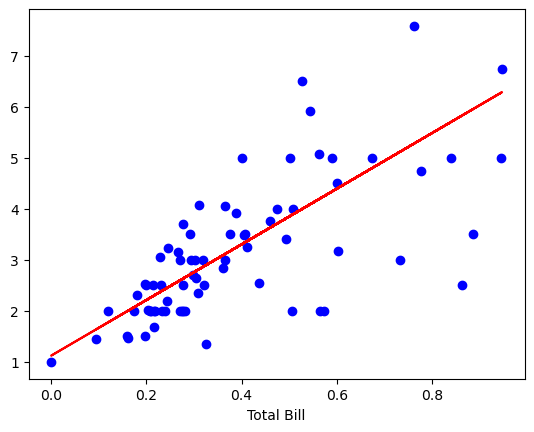

In [78]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Total Bill')

In [79]:
# save the model
import pickle
pickle.dump(model, open('./saved_models/model_01.pkl', 'wb'))

In [80]:
# load the model
import pickle
model_load = pickle.load(open('./saved_models/model_01.pkl', 'rb'))

In [81]:

model_load.predict([[1000]])

array([5451.73775343])